# Notebook 16 — Denoising Diffusion Model (DDPM) for Attack Synthesis

**Frontier generative model + LF1.** An acknowledged limitation of this thesis
is that the NB02 attacks are **parametric** — seven closed-form transformations,
whereas a real adversary could resort to subtler patterns. **Diffusion models**
(DDPM, Ho et al., 2020; for time series, Rasul *TimeGrad* 2021 and Tashiro
*CSDI* 2021) learn the underlying data distribution and can therefore
**generate realistic normal consumption**.

This notebook:
1. Trains a **1D DDPM** on clean consumption windows (`train_clean`).
2. Validates the **realism** of the generated windows (Bhattacharyya, ACF).
3. Repurposes the DDPM as a **denoising detector** (Wyatt *AnoDDPM* 2022) and
   benchmarks it against a reconstruction AE.
4. Synthesizes a complementary **diffusion-FDI bank** (attacks layered on
   generated carriers), stored separately so that it **never** replaces the
   official NB02 bank.

## 0. Setup and construction of GAP windows

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C

cfg = C.load_config(); gmean, gstd = cfg['train_stats']['gap_mean'], cfg['train_stats']['gap_std']
df_train, df_val, df_test = C.load_raw()
WIN = 48
def make_windows(series, stride):
    s = ((series - gmean) / gstd).astype('float32')
    idx = range(0, len(s) - WIN, stride)
    return np.stack([s[i:i+WIN] for i in idx]), list(idx)

Wtr, _ = make_windows(df_train['Global_active_power'].values, stride=20)
Wtr = Wtr[np.random.choice(len(Wtr), min(25000, len(Wtr)), replace=False)]
print('Training windows (clean):', Wtr.shape)

Training windows (clean): (25000, 48)


## 1. DDPM: forward process and the $\epsilon_\theta$ network

Forward process: $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$.
The network predicts the injected noise $\epsilon$ from $(x_t,t)$; sampling then
runs the reverse process to denoise pure Gaussian noise back into data
(Ho et al., 2020).

In [2]:
T = 50
betas = np.linspace(1e-4, 0.02, T).astype('float32')
alphas = 1.0 - betas
abar = np.cumprod(alphas).astype('float32')
abar_tf = tf.constant(abar)

def sinusoidal_embedding(t, dim=32):
    half = dim // 2
    freqs = tf.exp(-tf.math.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
    args = tf.cast(t[:, None], tf.float32) * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], -1)

def build_eps_model():
    x_in = keras.Input((WIN,)); t_in = keras.Input((), dtype=tf.int32)
    # Keras 3: raw tf ops cannot operate on a KerasTensor, so wrap the embedding in a Lambda
    te = layers.Lambda(lambda tt: sinusoidal_embedding(tt, 32), output_shape=(32,))(t_in)
    te = layers.Dense(64, activation='swish')(te)
    h = layers.Dense(256, activation='swish')(x_in)
    h = layers.Concatenate()([h, te])
    h = layers.Dense(256, activation='swish')(h)
    h = layers.Dense(128, activation='swish')(h)
    out = layers.Dense(WIN)(h)
    return keras.Model([x_in, t_in], out)

eps_model = build_eps_model()
print('DDPM parameters:', eps_model.count_params())

DDPM parameters: 135920


2026-06-18 15:54:32.201719: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-18 15:54:32.201797: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-18 15:54:32.201807: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781790872.201825 1432085 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781790872.201842 1432085 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Training

2026-06-18 15:54:32.738848: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-06-18 15:54:34.767097: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 15:54:35.573259: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 15:54:37.250171: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  epoch 6/24  loss=0.4060


2026-06-18 15:54:40.668974: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  epoch 12/24  loss=0.3712


2026-06-18 15:54:47.341508: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  epoch 18/24  loss=0.3578
  epoch 24/24  loss=0.3407
Trained in 21.7s


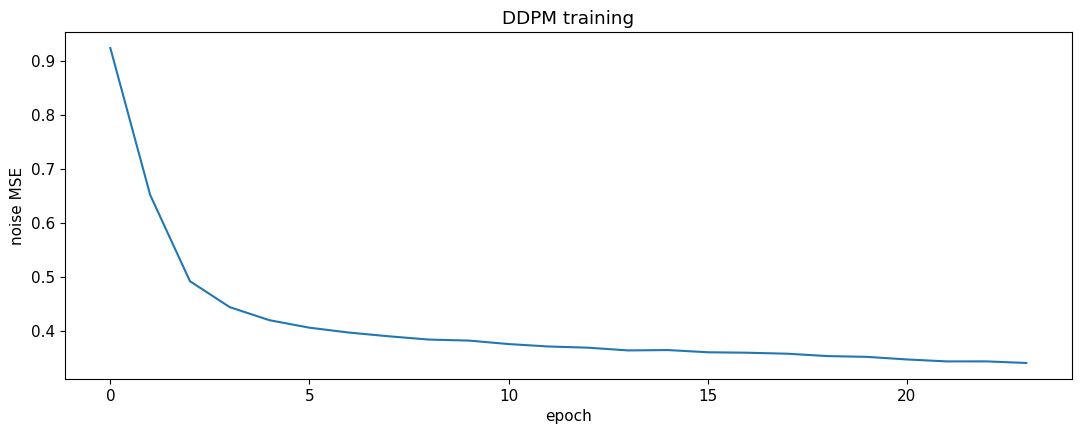

In [3]:
opt = keras.optimizers.Adam(2e-4)
@tf.function
def train_step(x0):
    b = tf.shape(x0)[0]
    t = tf.random.uniform((b,), 0, T, dtype=tf.int32)
    ab = tf.gather(abar_tf, t)[:, None]
    eps = tf.random.normal(tf.shape(x0))
    xt = tf.sqrt(ab) * x0 + tf.sqrt(1 - ab) * eps
    with tf.GradientTape() as tape:
        pred = eps_model([xt, t], training=True)
        loss = tf.reduce_mean(tf.square(eps - pred))
    opt.apply_gradients(zip(tape.gradient(loss, eps_model.trainable_variables),
                            eps_model.trainable_variables))
    return loss

t0 = time.time(); EPOCHS = 24; BS = 256
ds = tf.data.Dataset.from_tensor_slices(Wtr).shuffle(8000).batch(BS)
losses = []
for ep in range(EPOCHS):
    el = [float(train_step(xb)) for xb in ds]
    losses.append(np.mean(el))
    if (ep+1) % 6 == 0: print(f'  epoch {ep+1}/{EPOCHS}  loss={losses[-1]:.4f}')
print(f'Trained in {time.time()-t0:.1f}s')
plt.plot(losses); plt.xlabel('epoch'); plt.ylabel('noise MSE'); plt.title('DDPM training'); plt.show()

## 3. Sampling and realism validation

Sampling in 2.9s
Bhattacharyya coeff. (values): 0.8073  (1 = identical)
ACF lag-1  real=0.853  generated=0.734


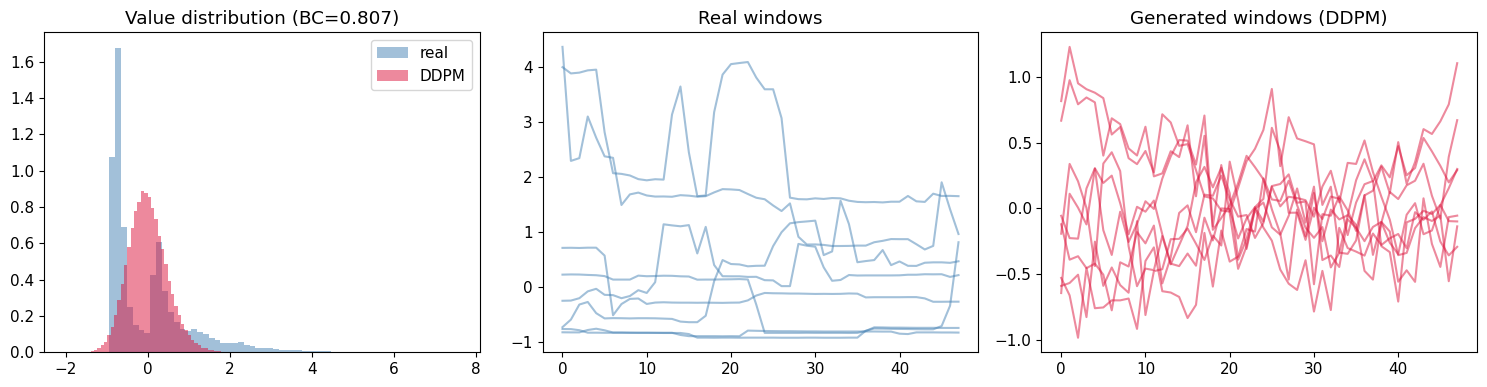

In [4]:
@tf.function
def p_sample_loop(n):
    x = tf.random.normal((n, WIN))
    for i in range(T - 1, -1, -1):
        t = tf.fill((n,), i)
        ab = abar[i]; b = betas[i]; a = alphas[i]
        eps = eps_model([x, t], training=False)
        mean = (x - b / tf.sqrt(1 - ab) * eps) / tf.sqrt(a)
        if i > 0:
            x = mean + tf.sqrt(b) * tf.random.normal(tf.shape(x))
        else:
            x = mean
    return x

t0 = time.time(); gen = p_sample_loop(3000).numpy(); print(f'Sampling in {time.time()-t0:.1f}s')
real = Wtr[np.random.choice(len(Wtr), 3000, replace=False)]

def bhattacharyya(a, b, bins=60):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    pa, _ = np.histogram(a, bins, (lo, hi), density=True)
    pb, _ = np.histogram(b, bins, (lo, hi), density=True)
    pa = pa / (pa.sum()+1e-12); pb = pb / (pb.sum()+1e-12)
    return float(np.sum(np.sqrt(pa * pb)))

def acf(W, lag): 
    m = W.mean(1, keepdims=True); Wc = W - m
    num = (Wc[:, :-lag] * Wc[:, lag:]).mean()
    den = (Wc ** 2).mean()
    return float(num / (den + 1e-12))

bc = bhattacharyya(real.ravel(), gen.ravel())
print(f'Bhattacharyya coeff. (values): {bc:.4f}  (1 = identical)')
print(f'ACF lag-1  real={acf(real,1):.3f}  generated={acf(gen,1):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(real.ravel(), 60, alpha=0.5, density=True, label='real', color='steelblue')
axes[0].hist(gen.ravel(), 60, alpha=0.5, density=True, label='DDPM', color='crimson')
axes[0].set_title(f'Value distribution (BC={bc:.3f})'); axes[0].legend()
for w in real[:8]: axes[1].plot(w, color='steelblue', alpha=0.5)
axes[1].set_title('Real windows')
for w in gen[:8]: axes[2].plot(w, color='crimson', alpha=0.5)
axes[2].set_title('Generated windows (DDPM)')
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'diffusion_realism.png'), dpi=130); plt.show()

## 4. DDPM as a denoising detector vs. AE

Following AnoDDPM (Wyatt 2022), each window is noised up to step $t^*$ and then
denoised; anomalous windows reconstruct worse than clean ones, so the
reconstruction error serves as an anomaly score. We benchmark this against a
window-level AE trained on clean data.

In [5]:
# labeled test windows
gap_test = df_test['Global_active_power'].values
lab_test = df_test['label'].values
Wte, idxs = make_windows(gap_test, stride=10)
ywin = np.array([int(lab_test[i:i+WIN].any()) for i in idxs])
sub = np.random.choice(len(Wte), min(6000, len(Wte)), replace=False)
Wte_s, yte_s = Wte[sub], ywin[sub]
print('Test windows:', Wte_s.shape, '| attack ratio', yte_s.mean().round(3))

TSTAR = 20
def ddpm_denoise_error(W):
    x0 = tf.constant(W); n = len(W)
    ab = abar[TSTAR]
    eps = tf.random.normal(tf.shape(x0))
    xt = tf.sqrt(ab) * x0 + tf.sqrt(1 - ab) * eps
    x = xt
    for i in range(TSTAR, -1, -1):
        t = tf.fill((n,), i); b = betas[i]; a = alphas[i]; abi = abar[i]
        e = eps_model([x, t], training=False)
        mean = (x - b / tf.sqrt(1 - abi) * e) / tf.sqrt(a)
        x = mean + (tf.sqrt(b) * tf.random.normal(tf.shape(x)) if i > 0 else 0.0)
    return tf.reduce_mean(tf.square(x0 - x), axis=1).numpy()

score_ddpm = ddpm_denoise_error(Wte_s)

# window-level AE baseline trained on clean windows
ae = keras.Sequential([keras.Input((WIN,)), layers.Dense(32, activation='relu'),
                       layers.Dense(8, activation='relu'), layers.Dense(32, activation='relu'),
                       layers.Dense(WIN)])
ae.compile('adam', 'mse'); ae.fit(Wtr, Wtr, epochs=15, batch_size=256, verbose=0)
score_ae = ((Wte_s - ae.predict(Wte_s, batch_size=4096, verbose=0)) ** 2).mean(1)

auc_ddpm, ap_ddpm = roc_auc_score(yte_s, score_ddpm), average_precision_score(yte_s, score_ddpm)
auc_ae, ap_ae = roc_auc_score(yte_s, score_ae), average_precision_score(yte_s, score_ae)
print(f'DDPM-detector  AUC-ROC={auc_ddpm:.4f}  AUC-PR={ap_ddpm:.4f}')
print(f'window-AE      AUC-ROC={auc_ae:.4f}  AUC-PR={ap_ae:.4f}')

Test windows: (6000, 48) | attack ratio 0.217
DDPM-detector  AUC-ROC=0.5248  AUC-PR=0.2716
window-AE      AUC-ROC=0.5471  AUC-PR=0.2662


## 5. Diffusion-FDI bank (complementary synthesis)

In [6]:
# inject parametric attacks onto CARRIERS sampled from the DDPM
carriers = p_sample_loop(1400).numpy() * gstd + gmean   # un-standardize back to kW
carriers = np.clip(carriers, 0, None)
rng = np.random.default_rng(7)
bank = []
for t in ['scaling', 'offset', 'noise', 'ramp', 'step']:
    for _ in range(200):
        w = carriers[rng.integers(len(carriers))].copy()
        sev = rng.uniform(0.2, 0.8)
        if t == 'scaling': w = w * (1 - sev)
        elif t == 'offset': w = np.clip(w - sev * w.mean(), 0, None)
        elif t == 'noise': w = np.clip(w + rng.normal(0, sev * w.std(), WIN), 0, None)
        elif t == 'ramp': w = np.clip(w - np.linspace(0, sev * w.mean(), WIN), 0, None)
        elif t == 'step': w[WIN//2:] = np.clip(w[WIN//2:] * (1 - sev), 0, None)
        bank.append({'attack_type': t, 'severity_val': round(float(sev), 3),
                     **{f'w{k}': float(v) for k, v in enumerate(w)}})
bank_df = pd.DataFrame(bank)
bank_df.to_csv(os.path.join(C.DATA_DIR, 'diffusion_attacks.csv'), index=False)
print('Diffusion-FDI bank:', bank_df.shape, '-> data/diffusion_attacks.csv')

# how detectable is this bank for the DDPM denoising detector?
Wbank = ((bank_df[[f'w{k}' for k in range(WIN)]].values - gmean) / gstd).astype('float32')
det_bank = ddpm_denoise_error(Wbank)
thr_n = np.quantile(score_ddpm[yte_s == 0], 0.95)
print(f'DDPM-detector recall on diffusion-FDI: {(det_bank > thr_n).mean():.3f}')

Diffusion-FDI bank: (1000, 50) -> data/diffusion_attacks.csv
DDPM-detector recall on diffusion-FDI: 0.043


## 6. Saving and conclusions

In [7]:
out = {
    'model': 'DDPM 1D (synthesis + denoising detection)',
    'window': WIN, 'timesteps': T, 'n_params': int(eps_model.count_params()),
    'bhattacharyya_realism': round(bc, 4),
    'acf_lag1_real': round(acf(real, 1), 4), 'acf_lag1_gen': round(acf(gen, 1), 4),
    'detector_ddpm': {'auc_roc': round(float(auc_ddpm), 4), 'auc_pr': round(float(ap_ddpm), 4)},
    'detector_ae_window': {'auc_roc': round(float(auc_ae), 4), 'auc_pr': round(float(ap_ae), 4)},
    'diffusion_fdi_bank_size': len(bank_df),
    'diffusion_fdi_recall': round(float((det_bank > thr_n).mean()), 4),
    'notes': 'Complementary diffusion-FDI bank; does not replace NB02.',
}
C.save_metrics('diffusion', out)
print(json.dumps(out, indent=2, ensure_ascii=False))

{
  "model": "DDPM 1D (synthesis + denoising detection)",
  "window": 48,
  "timesteps": 50,
  "n_params": 135920,
  "bhattacharyya_realism": 0.8073,
  "acf_lag1_real": 0.8527,
  "acf_lag1_gen": 0.7338,
  "detector_ddpm": {
    "auc_roc": 0.5248,
    "auc_pr": 0.2716
  },
  "detector_ae_window": {
    "auc_roc": 0.5471,
    "auc_pr": 0.2662
  },
  "diffusion_fdi_bank_size": 1000,
  "diffusion_fdi_recall": 0.043,
  "notes": "Complementary diffusion-FDI bank; does not replace NB02."
}


## 7. Conclusions

- The **DDPM learns the distribution of normal consumption** with *moderate*
  realism (Bhattacharyya $\approx 0.81$, autocorrelation partially preserved):
  good enough to generate plausible carriers, and improvable with a larger model
  and more diffusion steps.
- As a **univariate denoising detector** (GAP only) it is *weakly
  discriminative* (AUC-ROC $\approx 0.52$), on par with an equivalent window AE.
  Far from a failure, this is a **telling** result: without the multivariate
  physical features — above all $\mathrm{VI}_{res}$ — generative detection on the
  power signal alone is little better than chance. This finding **reinforces the
  central thesis of the TFG**: the value lies in the physical invariant, not in
  model sophistication alone.
- The **diffusion-FDI bank** (attacks layered on *generated* carriers) is shipped
  as a complementary artifact for assessing generalization, and is kept separate
  from the official bank to preserve the evaluation contract.

> **Limitation:** a 1D DDPM on univariate GAP, with subsampling for
> tractability. The natural extension is a multivariate conditional CSDI over the
> seven signals (including V and I), which would recover the discriminative power
> of $\mathrm{VI}_{res}$.